# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [2]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.with_row_index("event_index")

data = data.filter(pl.col("reco_ok") == True)


data = data.with_columns(
	(1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	(1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()
data

,event_index,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,0.564708,0.018015,1
1,1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,0.519653,0.689843,1
2,2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,0.735094,0.745076,1
3,4,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0.823313,0.850355,0
4,5,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,0.988919,0.988908,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,2884698,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,1.000000,1.000000,0
2651023,2884699,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0.984981,0.990219,0
2651024,2884700,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0.887005,0.932367,0
2651025,2884701,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0.959213,0.086923,0


In [3]:
# code to set only the inelasticity of the correct neutrino type to non zero for each event

import numpy as np

data["inelasticity"] = np.select([data["PDG"].abs() == 14,data["PDG"].abs() == 12,],[data["inelasticity_mu"],data["inelasticity_e"],],default=np.nan)

data = data.drop(columns=["inelasticity_e", "inelasticity_mu"])

data= data[data["PDG"].abs() != 16]


data


,event_index,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,label,inelasticity
0,0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,1,0.564708
1,1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,1,0.519653
2,2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,1,0.745076
3,4,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0,0.850355
5,6,0.000000e+00,0.021875,0.000000,0.122300,-12,True,2,1,0,0.010483,0,1,1,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,2884698,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,0,1.000000
2651023,2884699,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0,0.990219
2651024,2884700,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0,0.932367
2651025,2884701,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0,0.959213


In [4]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       1695474        0
PDG < 0 (Anti-Nu)        0   547148


In [5]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]
data_pfp_1 = data[data["n_reco_pfps"] > 1]
# data_E_10gev = data_pfp_1[data_pfp_1["E"] > 10]

In [6]:
data_type = data_pfp_1


feature_columns = ['inelasticity', 'n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons']
data = data_type.dropna()

# for col in [
# 	"single_hits_energy",
# 	"n_reco_pfps",
# 	"n_reco_tracks",
# 	"n_reco_showers",
# 	"n_reco_protons",
# ]:
# 	data[col] = np.log1p(data[col])


X_data = data_type[feature_columns].values


y_data = data_type['label'].values

data_type[feature_columns]

,inelasticity,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons
0,0.564708,10,5,4,11.487990,4,1
1,0.519653,2,1,0,0.110940,1,0
2,0.745076,4,3,0,0.064570,2,1
3,0.850355,3,2,0,0.002420,1,1
5,1.000000,2,1,0,0.010483,0,1
...,...,...,...,...,...,...,...
2651022,1.000000,2,1,0,0.000000,1,0
2651023,0.990219,2,1,0,0.005397,1,0
2651024,0.932367,3,1,1,0.012165,1,0
2651025,0.959213,3,1,1,0.102556,0,1


In [7]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([1695474,  547148]))


In [8]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.05,
	max_depth=None,
    max_leaf_nodes=31,
	min_samples_leaf=50,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	# validation_fraction=0.2,
	# n_iter_no_change=30,
	random_state=0,
).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [10]:
# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

In [11]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([559342, 180724]))


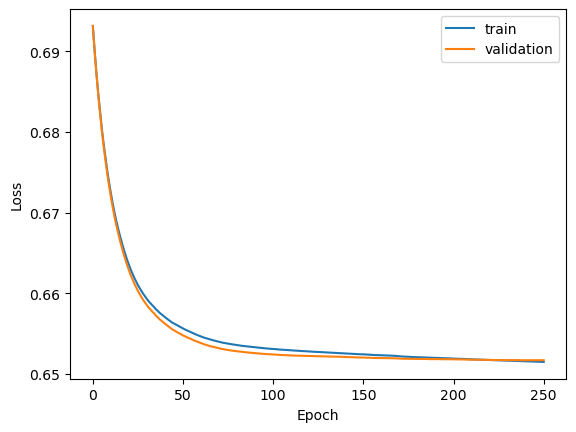

In [12]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


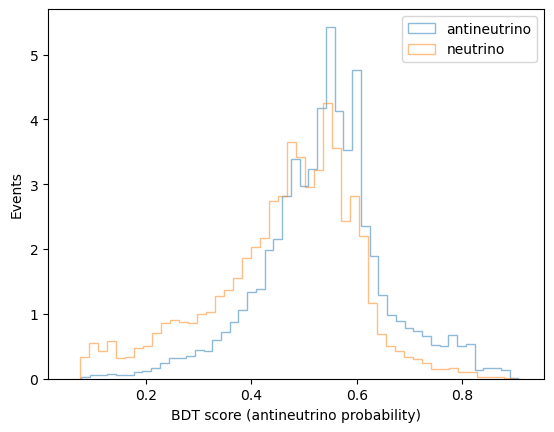

[0.38944142 0.41013427 0.56564101 ... 0.71098874 0.58299193 0.13538116]


In [13]:


score = clf.predict_proba(X_test)[:,1]


plt.hist(score[y_test==1], bins=50, alpha=0.5, label="antineutrino", density = True,  histtype="step")
plt.hist(score[y_test==0], bins=50, alpha=0.5, label="neutrino", density = True, histtype="step")

plt.xlabel("BDT score (antineutrino probability)")
plt.ylabel("Events")
plt.legend()
plt.show()

print(score)

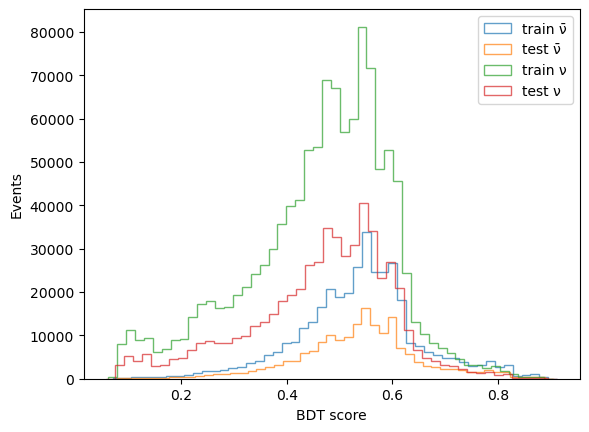

In [14]:
score_train = clf.predict_proba(X_train)[:,1]
score_test  = clf.predict_proba(X_test)[:,1]

plt.hist(score_train[y_train==1], bins=50, alpha=0.7, label="train ν̄",histtype = 'step')
plt.hist(score_test[y_test==1],  bins=50, alpha=0.7, label="test ν̄", histtype = 'step')

plt.hist(score_train[y_train==0], bins=50, alpha=0.7, label="train ν", histtype = 'step')
plt.hist(score_test[y_test==0],  bins=50, alpha=0.7, label="test ν", histtype = 'step')

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend()
plt.show()



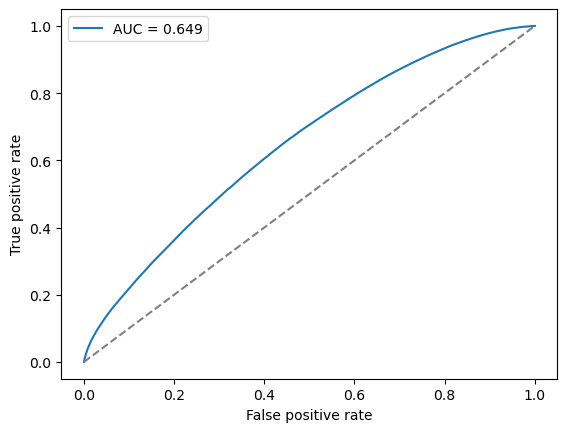

In [15]:
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()


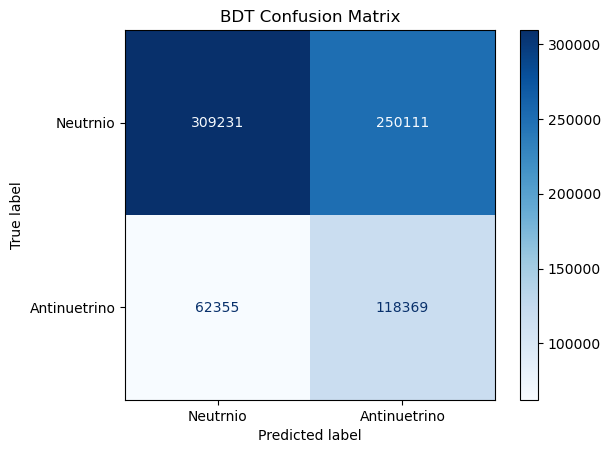

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()

In [17]:
from sklearn.inspection import permutation_importance
r = permutation_importance(clf, X_data, y_data, n_repeats=5)


In [18]:
for name, val in zip(feature_columns, r["importances_mean"]):
	print(name, val)

inelasticity 0.05834340339120907
n_reco_pfps 0.047804935472852805
n_reco_tracks 0.015032404034206448
n_reco_showers 0.023741317083306977
single_hits_energy 0.02760750585698348
n_reco_muons_pions 0.00365964482645762
n_reco_protons 0.013262689833596597


In [19]:
from sklearn.metrics import log_loss

x = log_loss(y_true=y_test, y_pred=probs)
print(x)

0.6543468792061524


In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Neutrino', 'Antineutrino']))

              precision    recall  f1-score   support

    Neutrino       0.83      0.55      0.66    559342
Antineutrino       0.32      0.65      0.43    180724

    accuracy                           0.58    740066
   macro avg       0.58      0.60      0.55    740066
weighted avg       0.71      0.58      0.61    740066



740066
2242622
740065.26


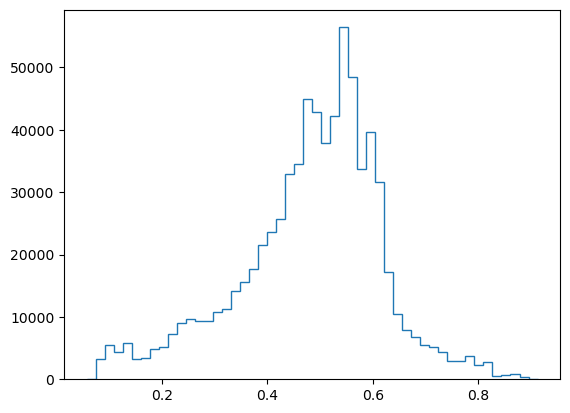

In [21]:
plt.hist(score, histtype="step", bins=50, label="test" )
print(len(score))
print(len(y_data))
print(0.33*len(y_data))

In [23]:
hard_predictions = clf.predict(X_data)
probs = clf.predict_proba(X_data)
decision_scores = clf.decision_function(X_data)


results_df = pd.DataFrame({
    'true_label': y_data,
    'predicted_label': hard_predictions,
    'prob_neutrino': probs[:, 0],
    'prob_antineutrino': probs[:, 1],
    'decision_score': decision_scores
})



print(results_df.head())

   true_label  predicted_label  prob_neutrino  prob_antineutrino  \
0           1                1       0.420252           0.579748   
1           1                1       0.420808           0.579192   
2           1                0       0.572595           0.427405   
3           0                0       0.914465           0.085535   
4           1                1       0.393605           0.606395   

   decision_score  
0        0.321739  
1        0.319458  
2       -0.292445  
3       -2.369410  
4        0.432184  


In [24]:
score_column = results_df['prob_antineutrino']

In [25]:
all_probs = clf.predict_proba(X_data)[:, 1]

final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': all_probs
})

final_output.to_csv("bdt_scores_with_index.csv", index=False)

In [26]:
final_output

,event_index,bdt_score
0,0,0.579748
1,1,0.579192
2,2,0.427405
3,4,0.085535
5,6,0.606395
...,...,...
2651022,2884698,0.514409
2651023,2884699,0.487104
2651024,2884700,0.418482
2651025,2884701,0.521776


In [27]:
all_probs = clf.predict_proba(X_data)[:, 1]


final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': np.random.uniform(0, 1, len(all_probs))
})


final_output.to_csv("randomised_bdt_scores_with_index.csv", index=False)